In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from math import sqrt

from sklearn.metrics import (mean_squared_error as MSE, mean_absolute_error as MAE, r2_score as R2,
                             explained_variance_score as EVS)
from sklearn.preprocessing import RobustScaler

from keras.models import load_model

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 8)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
def fraction_within_eps(y_true, y_pred, epsilon=0.5):
    # fraction of entries where abs(y_true - y_pred) < epsilon
    
    count = np.sum(np.abs(y_true - y_pred) <= epsilon)
    return count / y_true.shape[0]

yt = np.array([10, 10, 10, 10, 10])
yp = np.array([9.2, 9.7, 10.3, 10.2, 11])
print(fraction_within_eps(yt, yp, 0.6))
FIE = fraction_within_eps

0.6


In [7]:
def concorr(x, y):
    # Return Lin's concordance correlation coefficient
    # x, y are numpy arrays
    
    xm = x.mean()
    ym = y.mean()
    xv = x.var()
    yv = y.var()
    xycov = np.sum((x-xm)*(y-ym)) / x.shape[0]
    lin = 2*xycov / (xv + yv + (xm - ym)**2)
    return lin

xx = np.random.randn(10)
yy = xx + 10
print('R2 corr coef is {} whereas concordance corr coef is {}'.format(R2(yy,xx), concorr(yy,xx)))

R2 corr coef is -171.1745280728231 whereas concordance corr coef is 0.011482735289305861


In [8]:
with open('stations-6to31.pkl', 'rb') as f:
    datas = pickle.load(f)
    
x_train6_ = datas['x_train6']
y_train6 = datas['y_train6']
x_train_ = datas['x_train']
y_train = datas['y_train']
x_dev_ = datas['x_dev']
y_dev = datas['y_dev']
x_test_ = datas['x_test']
y_test = datas['y_test']

print(f'x_train shape: {x_train_.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [9]:
def scale_data(scaler, datas):
    # scaler is a scaling function from sklearn library
    # datas is a dictionary, containing 3 sets of x_data with keys - x_train, x_dev, x_test
    # fit on x_train and return the transformed sets of data
    
    x_train = scaler.fit_transform(datas['x_train'].astype(float))
    x_dev = scaler.transform(datas['x_dev'].astype(float))
    x_test = scaler.transform(datas['x_test'].astype(float))
    
    transformed = {'x_train': x_train, 'x_dev': x_dev, 'x_test': x_test}
    return transformed

data6_ = {'x_train': x_train6_, 'x_dev': x_dev_, 'x_test': x_test_}
data_ = {'x_train': x_train_, 'x_dev': x_dev_, 'x_test': x_test_}

data6 = scale_data(RobustScaler(), data6_)
data = scale_data(RobustScaler(), data_)

x_train6 = data6['x_train']
x_train = data['x_train']

x_dev6 = data6['x_dev']
x_dev = data['x_dev']

x_test6 = data6['x_test']
x_test = data['x_test']

print(f'x_train shape: {x_train.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [10]:
data6_3v_ = {'x_train': x_train6_[:, [1, 3, 4, 2]], 'x_dev': x_dev_[:, [1, 3, 4, 2]], 'x_test': x_test_[:, [1, 3, 4, 2]]}
data_3v_ = {'x_train': x_train_[:, [1, 3, 4, 2]], 'x_dev': x_dev_[:, [1, 3, 4, 2]], 'x_test': x_test_[:, [1, 3, 4, 2]]}

data6_3v = scale_data(RobustScaler(), data6_3v_)
data_3v = scale_data(RobustScaler(), data_3v_)

x_train6_3v = data6_3v['x_train']
x_train_3v = data_3v['x_train']

x_dev6_3v = data6_3v['x_dev']
x_dev_3v = data_3v['x_dev']

x_test6_3v = data6_3v['x_test']
x_test_3v = data_3v['x_test']

print(f'x_train shape: {x_train_3v.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_3v.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_3v.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_3v.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 4), y_train shape: (52416,)
x_train6 shape: (10654, 4), y_train6 shape: (10654,)
x_dev shape: (9011, 4), y_dev shape: (9011,)
x_test shape: (16899, 4), y_test shape: (16899,)


In [11]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test6 = []
metrics_train6 = []
metrics_dev6 = []
print('Evaluating metrics for 6station trained NN \n')
for i in range(50):
    modelname = './6to31stats-3vars-h/6stations-h-nNTH0 {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test6_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev6_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train6_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_train6, p )
    rmse = sqrt( mse )
    mae = MAE( y_train6, p )
    r2 = R2( y_train6, p )
    evs = EVS( y_train6, p )
    fie_h = FIE( y_train6, p, 0.5)
    fie_o = FIE( y_train6, p, 1)
    fie_oh = FIE( y_train6, p, 1.5)
    lin = concorr(y_train6, p)

    metrics_train6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 6station trained NN 

C01 » RMSE: 3.8789, MAE: 2.0504, R2: 0.7952, EVS: 0.7991, FIE_H: 0.2446, FIE_O: 0.4533, FIE_OH: 0.6145, LINCC: 0.8966
C01 » RMSE: 2.3788, MAE: 1.5684, R2: 0.9162, EVS: 0.9170, FIE_H: 0.2504, FIE_O: 0.4667, FIE_OH: 0.6418, LINCC: 0.9587
C01 » RMSE: 4.0908, MAE: 2.1301, R2: 0.8043, EVS: 0.8061, FIE_H: 0.2134, FIE_O: 0.4044, FIE_OH: 0.5725, LINCC: 0.8973
C02 » RMSE: 4.1555, MAE: 2.1843, R2: 0.7650, EVS: 0.7833, FIE_H: 0.2187, FIE_O: 0.4149, FIE_OH: 0.5780, LINCC: 0.8778
C02 » RMSE: 2.3930, MAE: 1.5661, R2: 0.9152, EVS: 0.9247, FIE_H: 0.2567, FIE_O: 0.4753, FIE_OH: 0.6470, LINCC: 0.9565
C02 » RMSE: 3.9855, MAE: 2.1840, R2: 0.8142, EVS: 0.8147, FIE_H: 0.2037, FIE_O: 0.3919, FIE_OH: 0.5400, LINCC: 0.8979
C03 » RMSE: 4.2058, MAE: 2.1409, R2: 0.7592, EVS: 0.7729, FIE_H: 0.2327, FIE_O: 0.4416, FIE_OH: 0.6019, LINCC: 0.8753
C03 » RMSE: 2.3308, MAE: 1.5009, R2: 0.9195, EVS: 0.9255, FIE_H: 0.2744, FIE_O: 0.5024, FIE_OH: 0.6657, LINCC: 0.9589
C03 » RMSE:

C24 » RMSE: 3.9682, MAE: 2.0070, R2: 0.8158, EVS: 0.8159, FIE_H: 0.2369, FIE_O: 0.4413, FIE_OH: 0.6153, LINCC: 0.9041
C25 » RMSE: 4.3532, MAE: 2.2212, R2: 0.7421, EVS: 0.7623, FIE_H: 0.2118, FIE_O: 0.4175, FIE_OH: 0.5860, LINCC: 0.8717
C25 » RMSE: 2.4293, MAE: 1.5929, R2: 0.9126, EVS: 0.9233, FIE_H: 0.2322, FIE_O: 0.4558, FIE_OH: 0.6360, LINCC: 0.9570
C25 » RMSE: 3.9993, MAE: 2.1462, R2: 0.8129, EVS: 0.8137, FIE_H: 0.1945, FIE_O: 0.3841, FIE_OH: 0.5464, LINCC: 0.9010
C26 » RMSE: 4.5528, MAE: 2.1944, R2: 0.7179, EVS: 0.7328, FIE_H: 0.2174, FIE_O: 0.4215, FIE_OH: 0.5961, LINCC: 0.8605
C26 » RMSE: 2.3637, MAE: 1.5125, R2: 0.9173, EVS: 0.9247, FIE_H: 0.2547, FIE_O: 0.4866, FIE_OH: 0.6698, LINCC: 0.9589
C26 » RMSE: 4.0151, MAE: 2.1430, R2: 0.8114, EVS: 0.8116, FIE_H: 0.1916, FIE_O: 0.3848, FIE_OH: 0.5474, LINCC: 0.9001
C27 » RMSE: 4.0887, MAE: 2.1756, R2: 0.7725, EVS: 0.7841, FIE_H: 0.2344, FIE_O: 0.4276, FIE_OH: 0.5853, LINCC: 0.8886
C27 » RMSE: 2.4077, MAE: 1.5765, R2: 0.9141, EVS: 0.9178

C48 » RMSE: 4.1314, MAE: 2.0738, R2: 0.7677, EVS: 0.7788, FIE_H: 0.2615, FIE_O: 0.4768, FIE_OH: 0.6361, LINCC: 0.8828
C48 » RMSE: 2.4021, MAE: 1.5292, R2: 0.9145, EVS: 0.9189, FIE_H: 0.2804, FIE_O: 0.5018, FIE_OH: 0.6597, LINCC: 0.9576
C48 » RMSE: 3.9846, MAE: 2.0460, R2: 0.8143, EVS: 0.8143, FIE_H: 0.2328, FIE_O: 0.4281, FIE_OH: 0.5918, LINCC: 0.9012
C49 » RMSE: 4.0869, MAE: 2.0556, R2: 0.7726, EVS: 0.7826, FIE_H: 0.2458, FIE_O: 0.4617, FIE_OH: 0.6305, LINCC: 0.8802
C49 » RMSE: 2.2605, MAE: 1.4307, R2: 0.9243, EVS: 0.9282, FIE_H: 0.2922, FIE_O: 0.5342, FIE_OH: 0.6983, LINCC: 0.9609
C49 » RMSE: 3.9760, MAE: 2.0951, R2: 0.8151, EVS: 0.8152, FIE_H: 0.2225, FIE_O: 0.4199, FIE_OH: 0.5817, LINCC: 0.8981
C50 » RMSE: 4.9703, MAE: 2.1889, R2: 0.6637, EVS: 0.6737, FIE_H: 0.2447, FIE_O: 0.4464, FIE_OH: 0.6042, LINCC: 0.8299
C50 » RMSE: 2.5224, MAE: 1.6116, R2: 0.9058, EVS: 0.9118, FIE_H: 0.2641, FIE_O: 0.4837, FIE_OH: 0.6447, LINCC: 0.9508
C50 » RMSE: 3.9483, MAE: 2.0766, R2: 0.8177, EVS: 0.8177

In [12]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test31 = []
metrics_train31 = []
metrics_dev31 = []
print('Evaluating metrics for 31station trained NN \n')
for i in range(50):
    modelname = './6to31stats-3vars-h/31stations-h-nNTH0 {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_train, p )
    rmse = sqrt( mse )
    mae = MAE( y_train, p )
    r2 = R2( y_train, p )
    evs = EVS( y_train, p )
    fie_h = FIE( y_train, p, 0.5)
    fie_o = FIE( y_train, p, 1)
    fie_oh = FIE( y_train, p, 1.5)
    lin = concorr(y_train, p)

    metrics_train31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 31station trained NN 

C01 » RMSE: 4.1070, MAE: 2.0798, R2: 0.7704, EVS: 0.7863, FIE_H: 0.2484, FIE_O: 0.4599, FIE_OH: 0.6239, LINCC: 0.8817
C01 » RMSE: 2.3410, MAE: 1.4624, R2: 0.9188, EVS: 0.9259, FIE_H: 0.2974, FIE_O: 0.5285, FIE_OH: 0.6885, LINCC: 0.9587
C01 » RMSE: 3.0380, MAE: 1.6692, R2: 0.8761, EVS: 0.8763, FIE_H: 0.2625, FIE_O: 0.4894, FIE_OH: 0.6569, LINCC: 0.9344
C02 » RMSE: 3.9185, MAE: 1.9741, R2: 0.7910, EVS: 0.8029, FIE_H: 0.2705, FIE_O: 0.4938, FIE_OH: 0.6503, LINCC: 0.8933
C02 » RMSE: 2.2731, MAE: 1.4213, R2: 0.9235, EVS: 0.9275, FIE_H: 0.3045, FIE_O: 0.5419, FIE_OH: 0.6990, LINCC: 0.9618
C02 » RMSE: 3.0173, MAE: 1.6208, R2: 0.8777, EVS: 0.8778, FIE_H: 0.2790, FIE_O: 0.5126, FIE_OH: 0.6787, LINCC: 0.9365
C03 » RMSE: 4.0409, MAE: 2.0313, R2: 0.7777, EVS: 0.7927, FIE_H: 0.2603, FIE_O: 0.4779, FIE_OH: 0.6395, LINCC: 0.8873
C03 » RMSE: 2.3308, MAE: 1.4465, R2: 0.9195, EVS: 0.9252, FIE_H: 0.2949, FIE_O: 0.5376, FIE_OH: 0.6988, LINCC: 0.9597
C03 » RMSE

C24 » RMSE: 2.2662, MAE: 1.4083, R2: 0.9239, EVS: 0.9282, FIE_H: 0.2993, FIE_O: 0.5517, FIE_OH: 0.7099, LINCC: 0.9619
C24 » RMSE: 3.0048, MAE: 1.6068, R2: 0.8788, EVS: 0.8788, FIE_H: 0.2783, FIE_O: 0.5208, FIE_OH: 0.6876, LINCC: 0.9368
C25 » RMSE: 4.0507, MAE: 2.0240, R2: 0.7767, EVS: 0.7902, FIE_H: 0.2688, FIE_O: 0.4817, FIE_OH: 0.6426, LINCC: 0.8859
C25 » RMSE: 2.3276, MAE: 1.4314, R2: 0.9198, EVS: 0.9248, FIE_H: 0.3084, FIE_O: 0.5462, FIE_OH: 0.6994, LINCC: 0.9598
C25 » RMSE: 3.0274, MAE: 1.6254, R2: 0.8769, EVS: 0.8769, FIE_H: 0.2775, FIE_O: 0.5101, FIE_OH: 0.6784, LINCC: 0.9358
C26 » RMSE: 4.0361, MAE: 2.1068, R2: 0.7783, EVS: 0.7963, FIE_H: 0.2242, FIE_O: 0.4306, FIE_OH: 0.6023, LINCC: 0.8882
C26 » RMSE: 2.3462, MAE: 1.5142, R2: 0.9185, EVS: 0.9267, FIE_H: 0.2539, FIE_O: 0.4837, FIE_OH: 0.6642, LINCC: 0.9597
C26 » RMSE: 3.0405, MAE: 1.6822, R2: 0.8759, EVS: 0.8763, FIE_H: 0.2470, FIE_O: 0.4745, FIE_OH: 0.6528, LINCC: 0.9359
C27 » RMSE: 3.9884, MAE: 2.0497, R2: 0.7835, EVS: 0.7988

C47 » RMSE: 3.0310, MAE: 1.6043, R2: 0.8766, EVS: 0.8768, FIE_H: 0.2863, FIE_O: 0.5255, FIE_OH: 0.6903, LINCC: 0.9368
C48 » RMSE: 3.9881, MAE: 2.0850, R2: 0.7835, EVS: 0.7992, FIE_H: 0.2313, FIE_O: 0.4370, FIE_OH: 0.6079, LINCC: 0.8872
C48 » RMSE: 2.2656, MAE: 1.4416, R2: 0.9240, EVS: 0.9304, FIE_H: 0.2820, FIE_O: 0.5208, FIE_OH: 0.6904, LINCC: 0.9612
C48 » RMSE: 3.0436, MAE: 1.6913, R2: 0.8756, EVS: 0.8757, FIE_H: 0.2543, FIE_O: 0.4783, FIE_OH: 0.6461, LINCC: 0.9339
C49 » RMSE: 4.2093, MAE: 2.0298, R2: 0.7588, EVS: 0.7656, FIE_H: 0.2617, FIE_O: 0.4806, FIE_OH: 0.6383, LINCC: 0.8796
C49 » RMSE: 2.2659, MAE: 1.4474, R2: 0.9240, EVS: 0.9261, FIE_H: 0.2821, FIE_O: 0.5145, FIE_OH: 0.6847, LINCC: 0.9623
C49 » RMSE: 3.0945, MAE: 1.6697, R2: 0.8714, EVS: 0.8719, FIE_H: 0.2628, FIE_O: 0.4928, FIE_OH: 0.6655, LINCC: 0.9337
C50 » RMSE: 4.0345, MAE: 2.0262, R2: 0.7784, EVS: 0.7930, FIE_H: 0.2576, FIE_O: 0.4767, FIE_OH: 0.6380, LINCC: 0.8861
C50 » RMSE: 2.2847, MAE: 1.4213, R2: 0.9227, EVS: 0.9283

In [13]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

with open('measures_6to31_nNT_h.pkl', 'wb') as f:
    pickle.dump(measures, f)

In [10]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

mess = ['rmse', 'mae', 'r2', 'evs', 'fie_h', 'fie_o', 'fie_oh', 'lin']
test6 = np.array(measures['te6']).T # 8x50
test31 = np.array(measures['te31']).T
for i in range(8):
    exec(f'{mess[i]} = np.array([test6[i], test31[i]])')
    exec(f'{mess[i]} = {mess[i]}.T')
    
print(rmse.shape)

(50, 2)


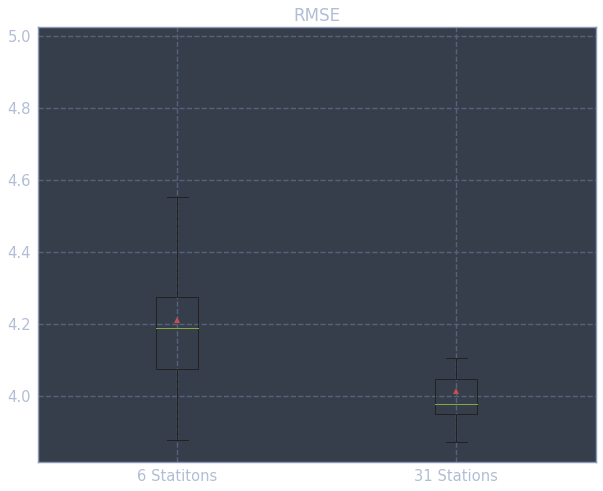

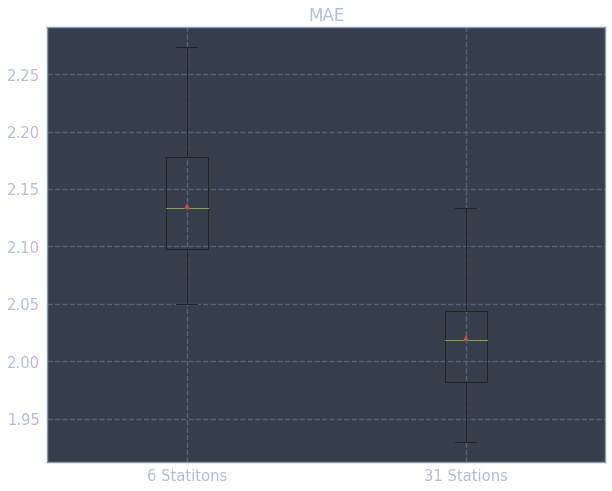

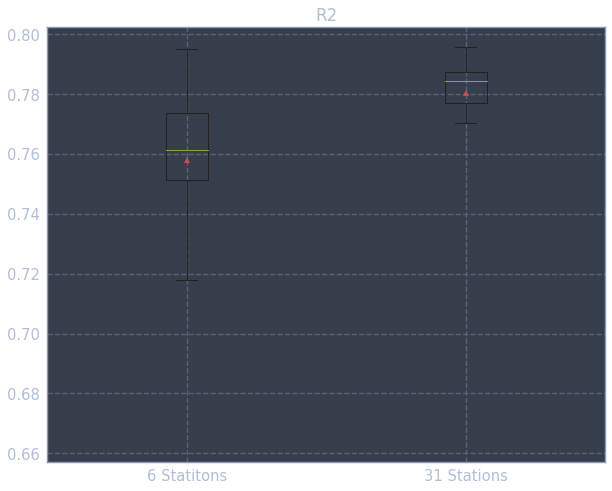

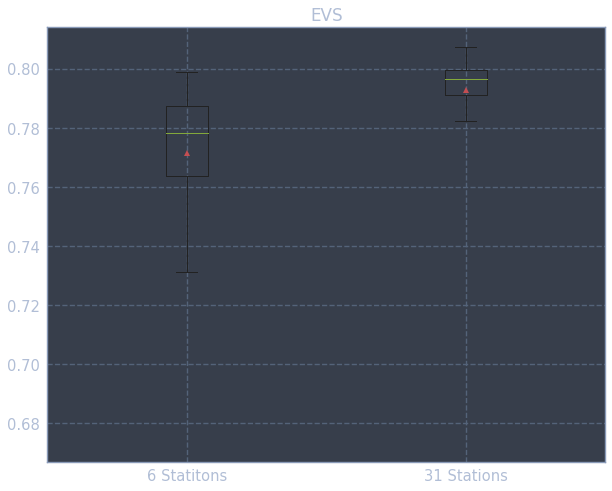

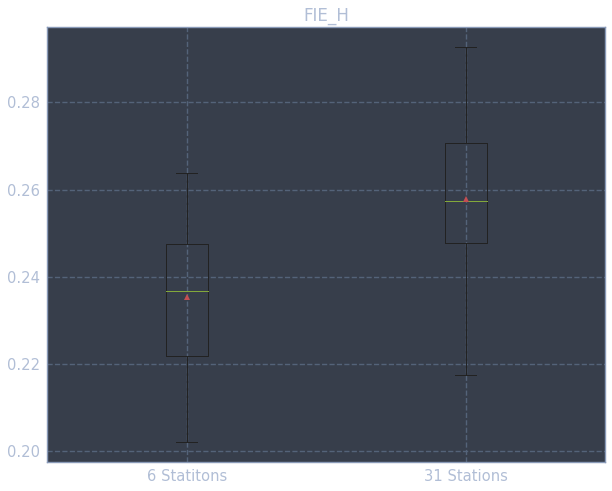

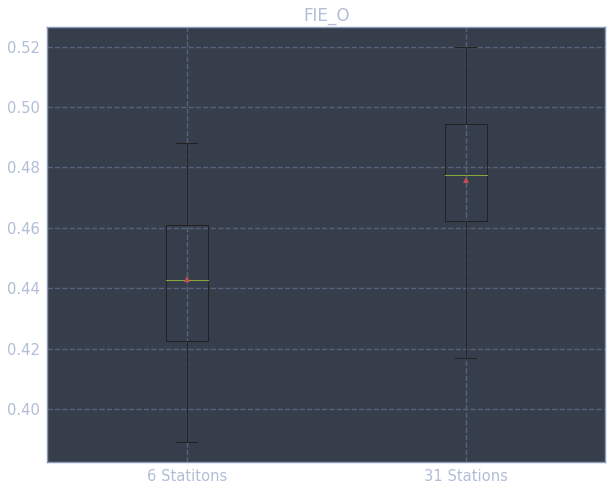

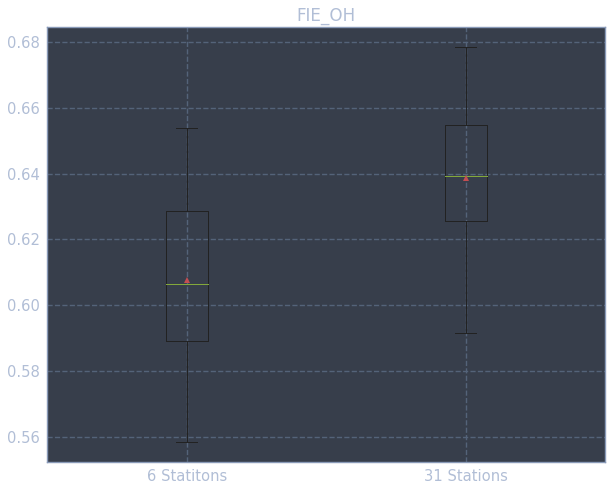

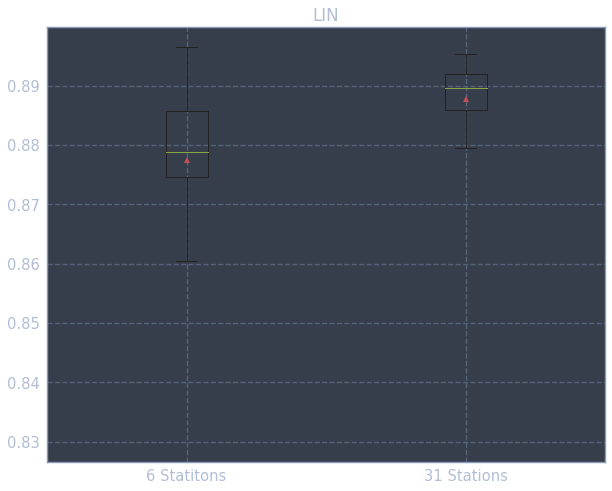

In [11]:
# I want a boxplot for each measure, showing test set comparison for 6station and 31station trained NNs
# plt.boxplot(x) makes a box for each column in x, so I need to feed 50x2 arrays to it

n = 0
for m in mess:
    plt.figure(n)
    exec(f'plt.boxplot({m}, labels=["6 Statitons", "31 Stations"], showmeans=True)')
    plt.title(m.upper())
    n += 1